# Semi-Lagrangian 

Here, we visualize the semi-Lagrangian isometries.

In [1]:
%load_ext autoreload
import torch
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.append('../..')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.set_default_dtype(torch.float64)

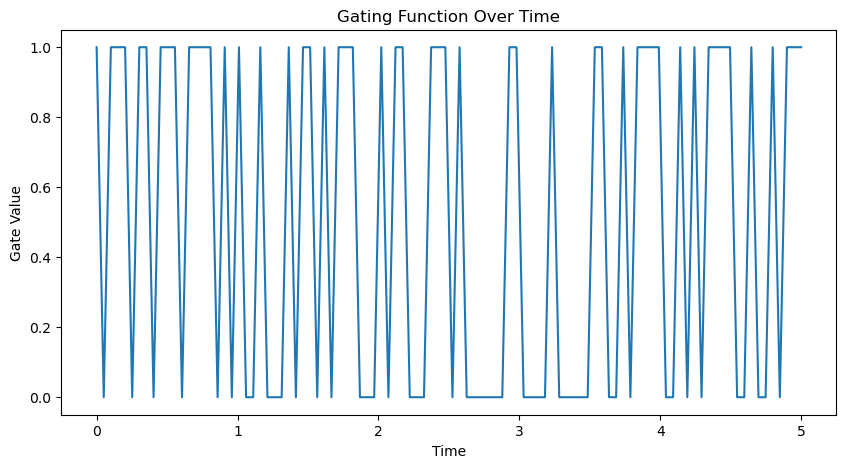

In [15]:
%autoreload 2 
from infidictionary.neural_isometries import SemiLagrangianIsometry
from infidictionary.utils import TimeEvolvingField
from infidictionary.utils import MLPNeuralField
from infidictionary.diffeomorphisms.continuous_time import CTRadialFlow
from infidictionary.domain_samplers import DiskSampler
import functools

start_time = 0.0
end_time = 5.0

torch.manual_seed(10)
N_per_dim = 50
T = CTRadialFlow(
    dimensions=2,
    gamma=1.,
    use_adjoint=True,
    method='dopri5',
    rtol=1e-6,
    atol=1e-6,
).to(device)

def custom_gating_function(t):
    # Example: a simple sigmoid gating function that transitions from 0 to 1 around t=2.5
    ret = 10 * (t - 2.5) # (B, )
    # add zero to make it (B, 2)
    ret = torch.stack([ret, -ret], dim=-1) # (B, 2)
    return ret

isometry = SemiLagrangianIsometry(
    coords_dim=2,
    channels_dim=1,
    scalar_field_partial=functools.partial(
        TimeEvolvingField,
        base_field_partial=functools.partial(
            MLPNeuralField,
            hidden_dims=dict(a=64, b=64),
            activation=torch.nn.ReLU,
        ),
    ),
    diffeomorphism=T,
    gating_function=None,
).to(device)


# visualize gating
tspan_large = torch.linspace(start_time, end_time, steps=100).to(device)
gate_values = isometry._compute_gating(tspan_large)
plt.figure(figsize=(10, 5))
plt.plot(tspan_large.cpu().detach(), gate_values[:, 0].cpu().detach())
plt.xlabel('Time')
plt.ylabel('Gate Value')
plt.title('Gating Function Over Time')
plt.show()


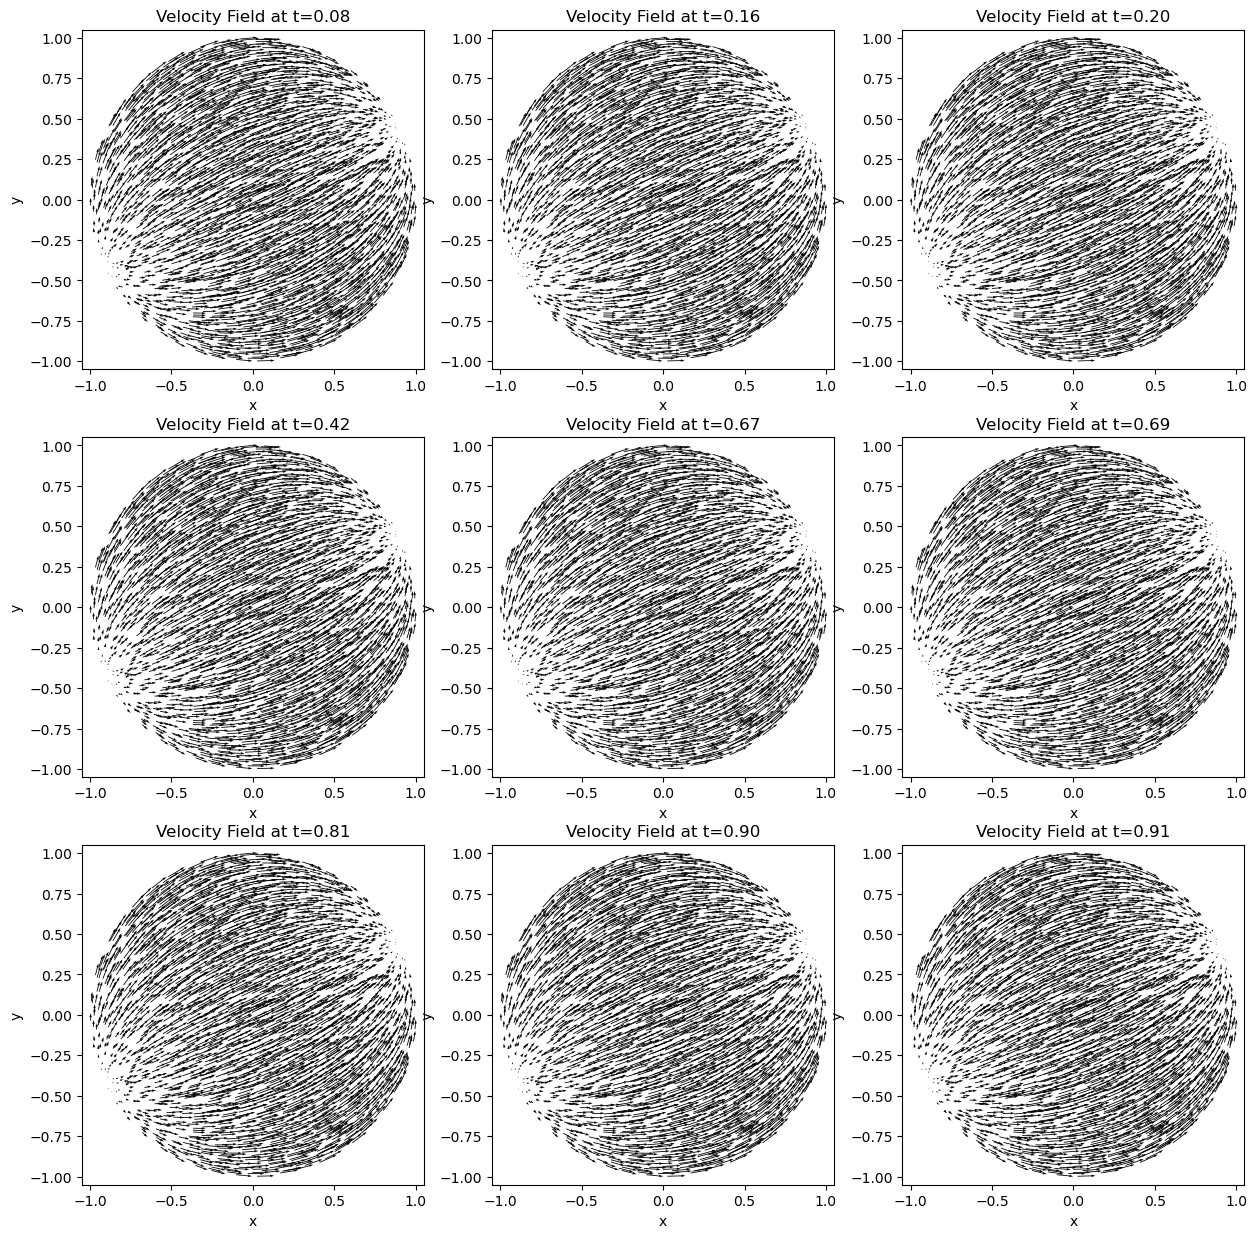

In [16]:
%autoreload 2
from infidictionary.diffeomorphisms.continuous_time import CTRadialFlow
from infidictionary.domain_samplers import DiskSampler

torch.manual_seed(10)
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(15,15))
N_per_dim = 50
viz_magnitude = 10.0

xy = DiskSampler().sample(N_per_dim).to(device)
N = xy.shape[0]

# sample 9 random times in [0,1] and sample
# the velocity field at those times at random points
# on the domain
t = torch.rand(9).to(device)
t, _ = torch.sort(t)
t = torch.repeat_interleave(t, N)
xy_repeated = xy.repeat(9, 1)
v = viz_magnitude * isometry.lagrangian.diffeomorphism.velocity_field(t, xy_repeated)

for row in range(3):
    for col in range(3):
        ax = axes[row, col]
        idx = row * 3 + col
        ax.quiver(xy_repeated[idx * N:(idx + 1) * N,0].detach().cpu(), xy_repeated[idx * N:(idx + 1) * N,1].detach().cpu(),
                  v[idx * N:(idx + 1) * N,0].detach().cpu(), v[idx * N:(idx + 1) * N,1].detach().cpu(),
                  angles='xy', scale_units='xy', scale=10.0, alpha=1)
        ax.set_title(f'Velocity Field at t={t[idx * N].item():.2f}')
        ax.set_xlim(-1.05,1.05)
        ax.set_ylim(-1.05,1.05)
        ax.set_xlabel('x')
        ax.set_ylabel('y')
plt.show()


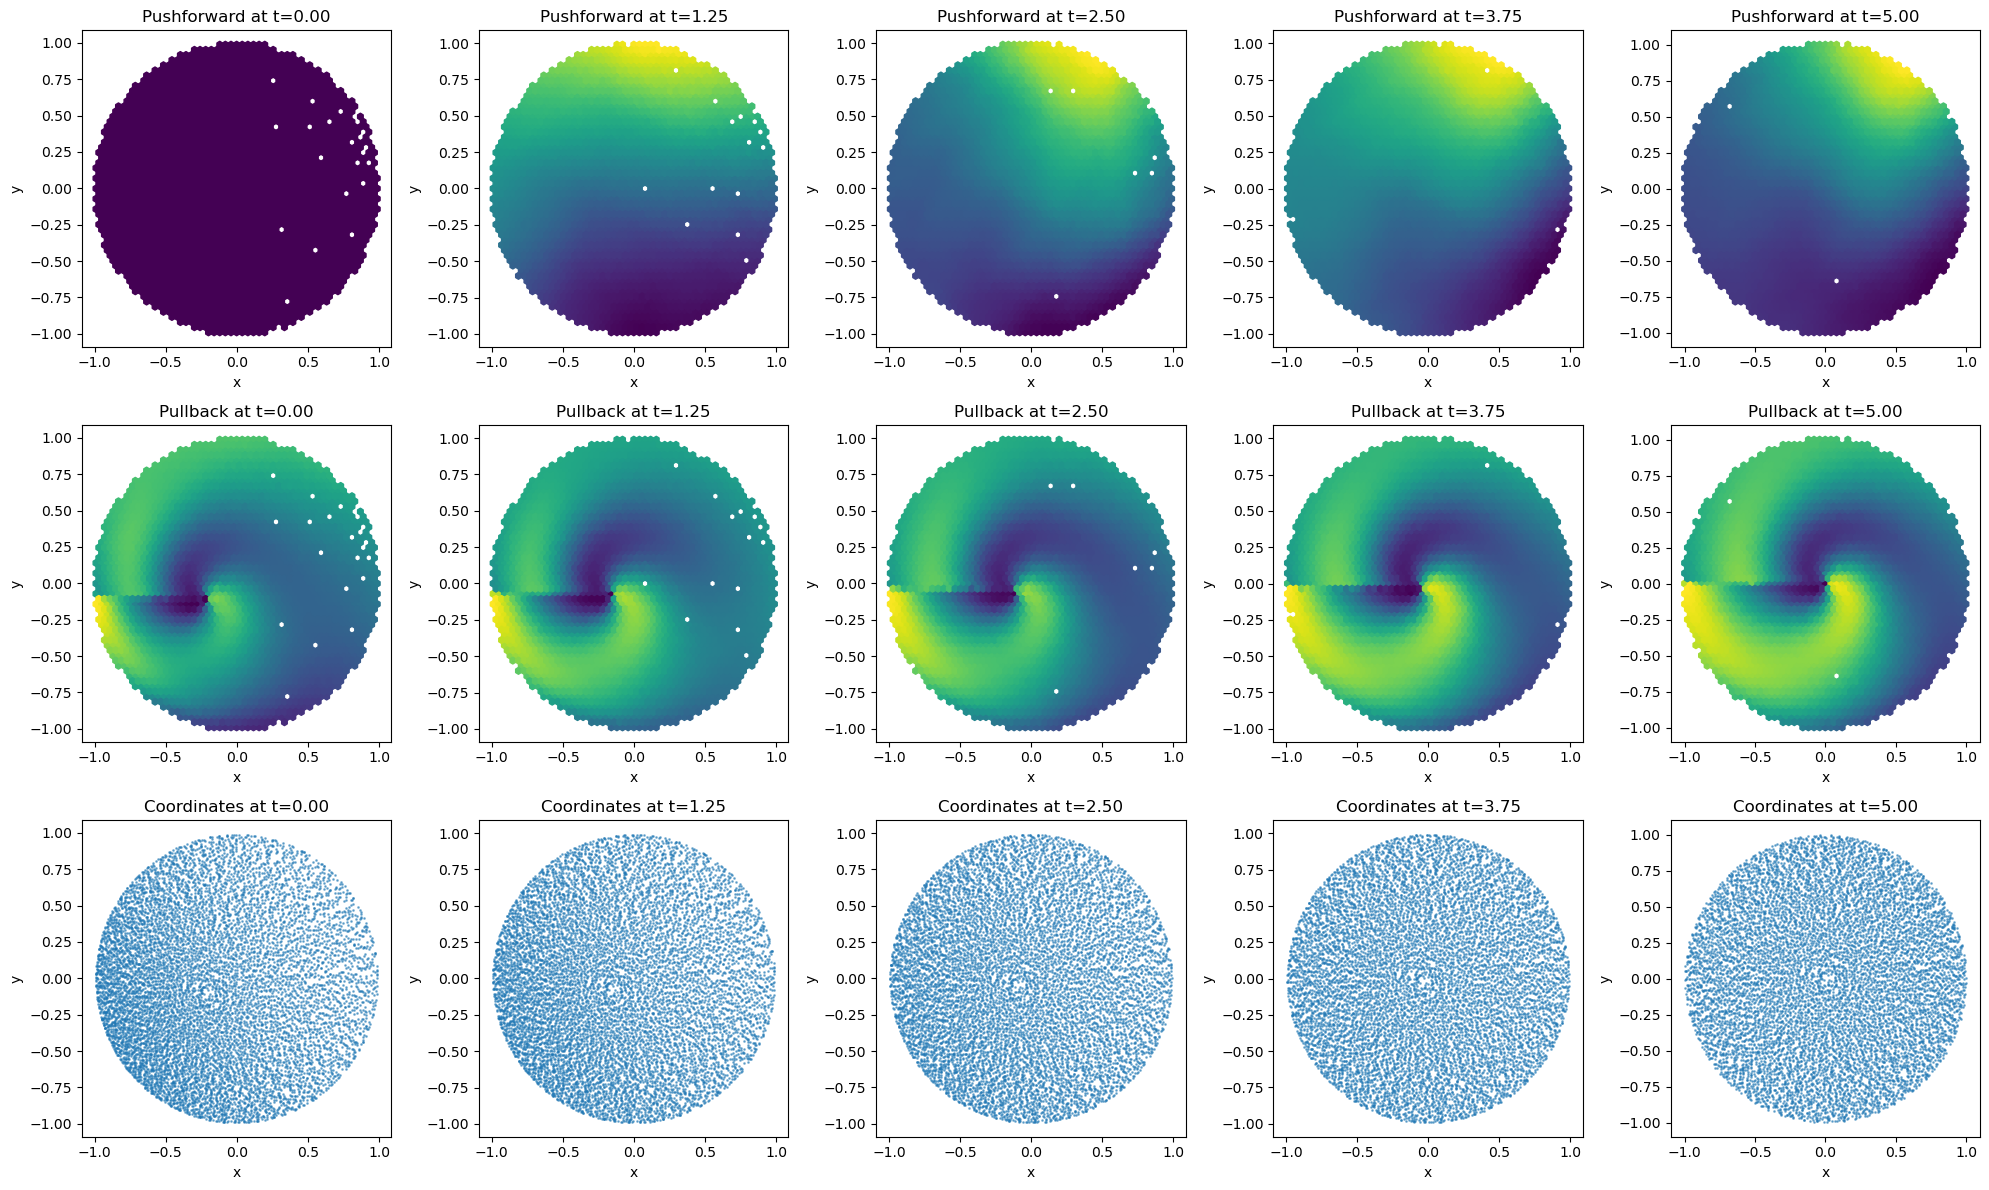

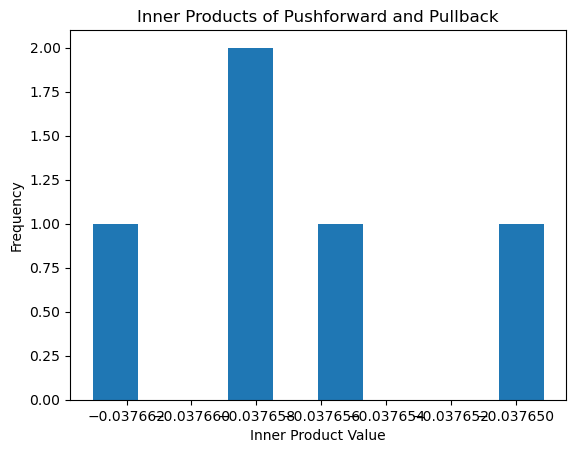

tensor([-0.0377, -0.0377, -0.0377, -0.0377, -0.0376])


In [21]:
%autoreload 2 
from infidictionary.datasets import RandomBandpassGenerator
from infidictionary.neural_isometries import LagrangianIsometry
from infidictionary.dictionaries import RadialFourierDictionary
from infidictionary.utils import parallel_inner_product
from infidictionary.diffeomorphisms import ShirlyChiu, PolarTransform

n_frames = 5
N_per_dim = 100
inner_steps = 10

isometry_domain = LagrangianIsometry(diffeomorphism=PolarTransform()).to(device)
isometry.reshuffle_time_discretization(num_steps=inner_steps)
# isometry.eval()
bandpass_gen = RandomBandpassGenerator(
    radial=True,
    omega_lo=5,
    omega_hi=10,
    r_lo=0.5,
    r_hi=1.0,
    l_sin=5,
    l_cos=5,
    seed=1024,
)
sampler2 = DiskSampler(stratified=True, add_noise=True)
coords2 = sampler2.sample(N_per_dim).to(device)
f = bandpass_gen.get_batch(
    coords2,
    seeds=torch.tensor([42]),
).unsqueeze(-1).to(device)

# --------------------------------------------------------
f_pullback = f.clone().detach().cpu() # (1, N, 1)
tspan = torch.linspace(start_time, end_time, steps=n_frames).to(device).flip(0)
logabsdet = torch.zeros(f.shape[1], device=f.device) # start from the last logabsdet value from the pushforward sequence since the pullback sequence is in reverse order
all_logabsdet2 = logabsdet.clone().unsqueeze(0).detach().cpu() # (1, N)
last_f = f
all_coords2 = coords2.clone().unsqueeze(0).detach().cpu() # (1, N, 2)
for t1, t0 in zip(tspan[:-1], tspan[1:]):
    coords2, logabsdet, last_f = isometry.pullback(
        coords2,
        logabsdet,
        last_f,
        start_time=t0.item(),
        end_time=t1.item(),
    )
    f_pullback = torch.cat([last_f.clone().detach().cpu(), f_pullback], dim=0)
    all_coords2 = torch.cat([coords2.clone().unsqueeze(0).detach().cpu(), all_coords2], dim=0) # (n_frames, N, 2)
    all_logabsdet2 = torch.cat([logabsdet.clone().unsqueeze(0).detach().cpu(), all_logabsdet2], dim=0) # (n_frames, N)


# --------------------------------------------------------
coords1 = coords2.clone()
phi = RadialFourierDictionary().get_atom(coords1, torch.tensor([0]).to(device)).unsqueeze(-1).to(device).unsqueeze(0) # (1, N, 1)
phi_pushforward = phi.clone().detach().cpu() # (1, N, 1)
tspan = torch.linspace(start_time, end_time, steps=n_frames).to(device)
all_coords1 = coords1.clone().unsqueeze(0).detach().cpu() # (1, N, 2)
all_logabsdet1 = logabsdet.clone().unsqueeze(0).detach().cpu() # (1, N)
last_phi = phi
for t0, t1 in zip(tspan[:-1], tspan[1:]):
    coords1, logabsdet, last_phi = isometry.pushforward(
        coords1,
        logabsdet,
        last_phi,
        start_time=t0.item(),
        end_time=t1.item(),
    )
    all_coords1 = torch.cat([all_coords1, coords1.clone().unsqueeze(0).detach().cpu()], dim=0) # (n_frames, N, 2)
    all_logabsdet1 = torch.cat([all_logabsdet1, logabsdet.clone().unsqueeze(0).detach().cpu()], dim=0) # (n_frames, N)
    phi_pushforward = torch.cat([phi_pushforward, last_phi.clone().detach().cpu()], dim=0) # (n_frames, N, 1)


diff = torch.abs(all_coords1 - all_coords2).max().item()
assert (all_coords1 - all_coords2).abs().max() < 1e-1, f"Coordinates from pushforward and pullback do not match, got max abs difference of {diff}"

fig, axes = plt.subplots(nrows=3, ncols=n_frames, figsize=(4 * n_frames, 3 * 4))
tspan = torch.linspace(start_time, end_time, steps=n_frames).to(device)
for i in range(n_frames):
    coords = all_coords2[i]
    pushforward_vals = phi_pushforward[i,:,0]
    pullback_vals = f_pullback[i,:,0]

    axes[0, i].hexbin(coords[:, 0], coords[:, 1], C=pushforward_vals, gridsize=50, cmap='viridis')
    axes[0, i].set_title(f'Pushforward at t={tspan[i].item():.2f}')
    axes[0, i].set_xlabel('x')
    axes[0, i].set_ylabel('y')

    axes[1, i].hexbin(coords[:, 0], coords[:, 1], C=pullback_vals, gridsize=50, cmap='viridis')
    axes[1, i].set_title(f'Pullback at t={tspan[i].item():.2f}')
    axes[1, i].set_xlabel('x')
    axes[1, i].set_ylabel('y')

    # scatterplot for coordinates
    axes[2, i].scatter(coords[:, 0].detach().cpu(), coords[:, 1].detach().cpu(), s=1, alpha=0.5)
    axes[2, i].set_title(f'Coordinates at t={tspan[i].item():.2f}')
    axes[2, i].set_xlabel('x')
    axes[2, i].set_ylabel('y')


plt.tight_layout()
plt.show()

all_inner_products = parallel_inner_product(
    phi_pushforward, f_pullback, all_logabsdet1
)
plt.hist(all_inner_products.cpu().detach())
plt.title('Inner Products of Pushforward and Pullback')
plt.xlabel('Inner Product Value')
plt.ylabel('Frequency')    
plt.show()

print(all_inner_products)